## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [10]:

import sys
import os
sys.path.append('../TCT/')
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import neighborhood_finder

from TCT import TCT



### Load Translator resources


In [3]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'url': '/sipr'}


In [ ]:
#Translator_KP_info

In [4]:
All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

# generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

## Find the neighborhood of an entity from a subset of APIs 


In [5]:
# select a list of APIs to use and a list of predicates to use, if the list is empty, use all APIs and predicates
#selected_APIlist = ['Microbiome KP - TRAPI 1.5.0']
selected_APIlist = []
if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)


{'ARAX Translator Reasoner - TRAPI 1.6.0': 'https://arax.transltr.io/api/arax/v1.4/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'SPOKE KP for TRAPI 1.5': 'https://spokekp.transltr.io/api/v1.5/query/', 'Automat-ubergraph(Trapi v1.5.0)': 'https://automat.renci.org/ubergraph/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Knowledge Collaboratory API': 'https://collaboratory-api.transltr.io/query/', 'Text Mined Cooccurrence API': 'https://cooccurrence.ci.transltr.io/query/', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'COHD TRAPI': 'https://cohd-api.transltr.io

In [6]:
name_resolver.lookup('acute myeloid leukemia', return_top_response=False, biolink_type='biolink:Disease',  limit=100) # sometimes the identifiers are not in the top 1, users need to check the other returned results


[TranslatorNode(curie='MONDO:0018874', label='acute myeloid leukemia', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None, attributes=None, taxa=[]),
 TranslatorNode(curie='MONDO:0005223', label='acute myeloid leukemia with minimal differentiation', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None, attributes=None, taxa=[]),
 TranslatorNode(curie='MONDO:0017893', label='inherited acute myeloid leukemia', types=['biolink:Disease', 'biolink:DiseaseOrPhenotypicFeature', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity'], synonyms=None, curie_synonyms=None, attributes=None, taxa=[]),
 TranslatorNode(curie='MONDO:0020317', label='acute myeloid leukemia with 11q23 ab

In order to use the neighborhood finder, we have to look up a CURIE ID for a given term.

In [7]:
#name_resolver.lookup('BCL2')
#name_resolver.lookup('BCL2', return_top_response=False, biolink_type='biolink:Gene',  limit=100, only_taxa='NCBITaxon:9606') # sometimes the identifiers are not in the top 1, users need to check the other returned results

input_identifiers = 'MONDO:0018874'


Neighborhood finder identifies all nodes *b* that are connected to the given node *a*, where *b* is part of a defined list of categories - returning the neighborhood of node *a*.

In [8]:
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neighborhood_finder('MONDO:0018874',
                                                                                            node2_categories = ['biolink:Disease'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

MONDO:0018874
Automat-monarchinitiative(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
Automat-drug-central(Trapi v1.5.0): Success!
Automat-ubergraph(Trapi v1.5.0): Success!
Automat-reactome(Trapi v1.5.0): Success!
Automat-gwas-catalog(Trapi v1.5.0): Success!
Automat-pharos(Trapi v1.5.0): Success!
Automat-ctd(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Text Mined Cooccurrence API: Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
orphanet:98277: no preferred name
orphanet:524: no preferred name
orphanet:98827: no preferred name
NodeNorm does not know about these identifiers: OMIM:MTHU010293,OMIM:MTHU020408,OMIM:MTHU020414,OMIM:MTHU034946,CHV:0000007343,UMLS:C2826176,CHV:0000050375,CHV:0000007348,MONDO:0975868,MONDO:0975870,MONDO:0975871,MONDO:0975872,MONDO:0044354,MONDO:0006560,MONDO:0007140,MONDO:0003540,MONDO:0005307,MONDO:0020312,MONDO:0005203,MONDO:0002454,MONDO:0005190,MONDO:0044

In [17]:
TCT_path_finder_result = neighborhood_finder.parse_results_for_neighborhood_finder(input_identifiers, result,
        start_node_categories='biolink:Disease', end_node_categories=None,
        get_node_info=True,
        scoring_method='infores')

In [18]:
# write a result to a json file
import json
with open('_TestTCT_neighborhood_finder_result_'+input_identifiers.replace(':', '_')+'.json', 'w') as f:
    json.dump(TCT_path_finder_result, f)

orphanet:98827: no preferred name
orphanet:524: no preferred name
orphanet:98277: no preferred name
NodeNorm does not know about these identifiers: MONDO:0007140,MONDO:0004721,MONDO:0975868,MONDO:0975872,MONDO:0975871,MONDO:0975870,HP:0011016,HP:0000001,MONDO:0009410,CHV:0000007343,MONDO:0015938,MONDO:0020078,MONDO:0010107,MONDO:0008345,MONDO:0011469,MONDO:0008674,MONDO:0019126,MONDO:0016784,MONDO:0000839,DOID:0070633,DOID:0070632,UMLS:C0524869,MONDO:0020315,DOID:0070629,DOID:0070630,DOID:0070631,MONDO:0006516,MONDO:0019044,MONDO:0043707,MONDO:0005547,MONDO:0019341,MONDO:0003540,MONDO:0005307,MONDO:0006560,MONDO:0044684,MONDO:0005203,MONDO:0020312,MONDO:0002454,MONDO:0005190,OMIM:MTHU010293,OMIM:MTHU020408,OMIM:MTHU020414,OMIM:MTHU034946,CHV:0000050375,CHV:0000007348,MONDO:0044354,UMLS:C2826176,MONDO:0006147,MONDO:0002176,MONDO:0021178,MONDO:0003629,MONDO:0017011,MONDO:0018262,MONDO:0007264,MONDO:0016665,MONDO:0020050,MONDO:0004955,MONDO:0002335,MONDO:0006785,MONDO:0044876,MONDO:000152

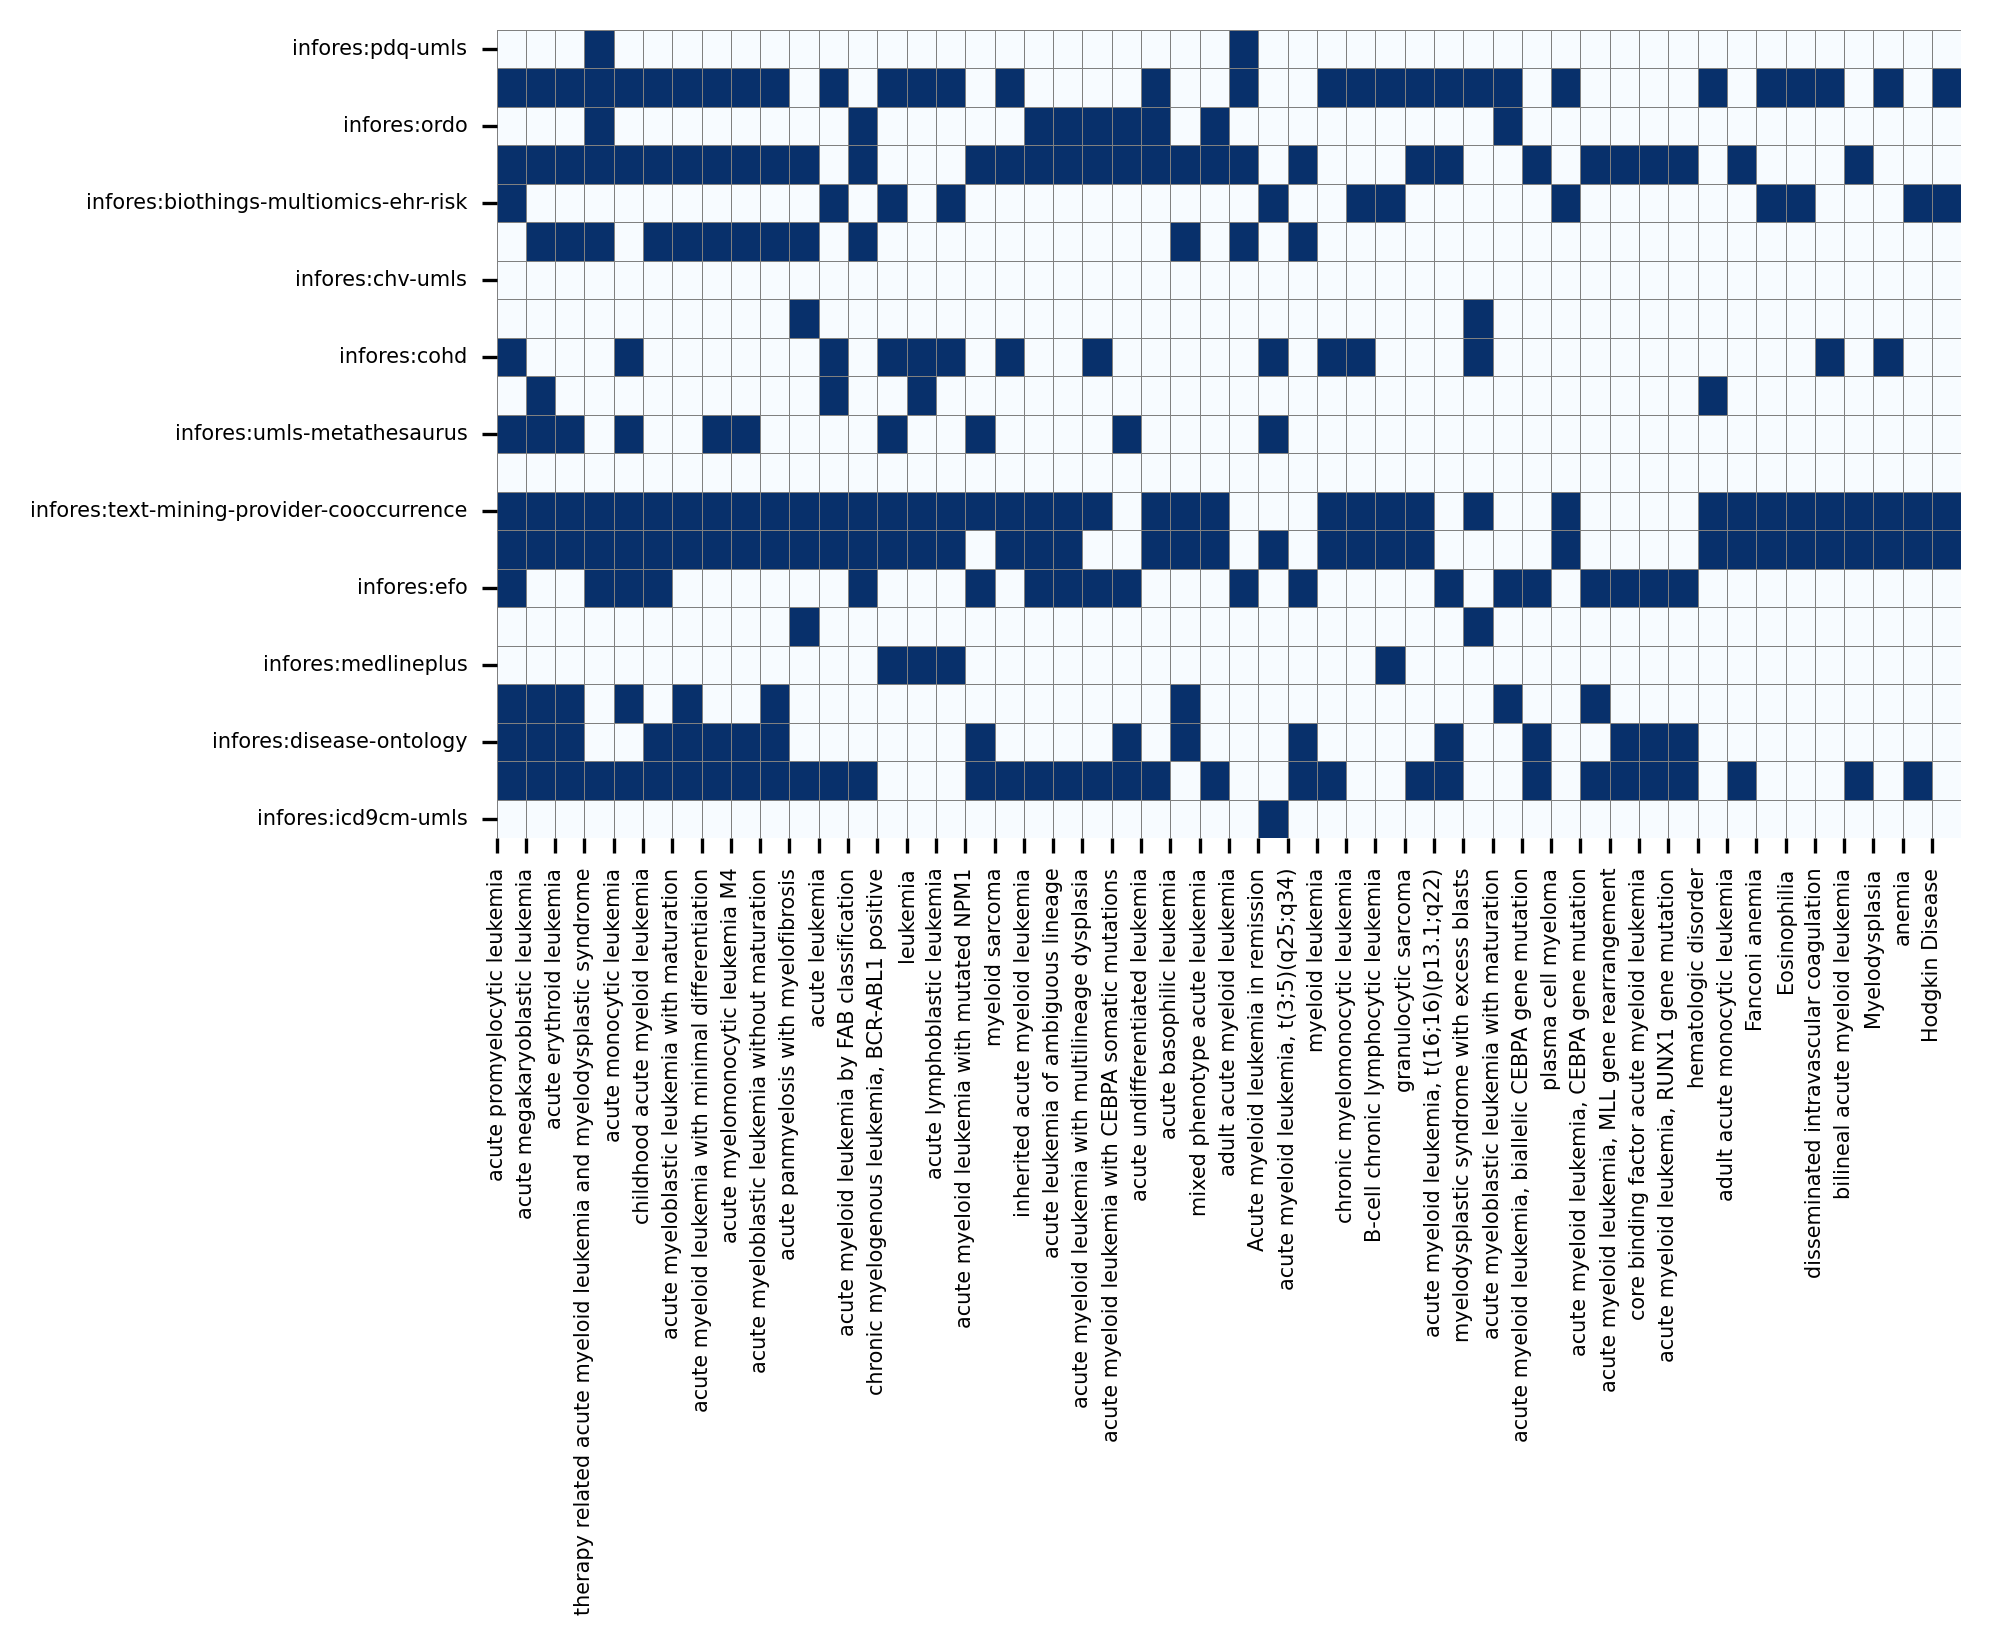

[Text(0.5, 0, 'acute promyelocytic leukemia'), Text(2.5, 0, 'acute erythroid leukemia'), Text(4.5, 0, 'acute monocytic leukemia'), Text(6.5, 0, 'acute myeloblastic leukemia with maturation'), Text(8.5, 0, 'acute myelomonocytic leukemia M4'), Text(10.5, 0, 'acute panmyelosis with myelofibrosis'), Text(12.5, 0, 'acute myeloid leukemia by FAB classification'), Text(14.5, 0, 'leukemia'), Text(16.5, 0, 'acute myeloid leukemia with mutated NPM1'), Text(18.5, 0, 'inherited acute myeloid leukemia'), Text(20.5, 0, 'acute myeloid leukemia with multilineage dysplasia'), Text(22.5, 0, 'acute undifferentiated leukemia'), Text(24.5, 0, 'mixed phenotype acute leukemia'), Text(26.5, 0, 'Acute myeloid leukemia in remission'), Text(28.5, 0, 'myeloid leukemia'), Text(30.5, 0, 'B-cell chronic lymphocytic leukemia'), Text(32.5, 0, 'acute myeloid leukemia, t(16;16)(p13.1;q22)'), Text(34.5, 0, 'acute myeloblastic leukemia with maturation'), Text(36.5, 0, 'plasma cell myeloma'), Text(38.5, 0, 'acute myeloid l

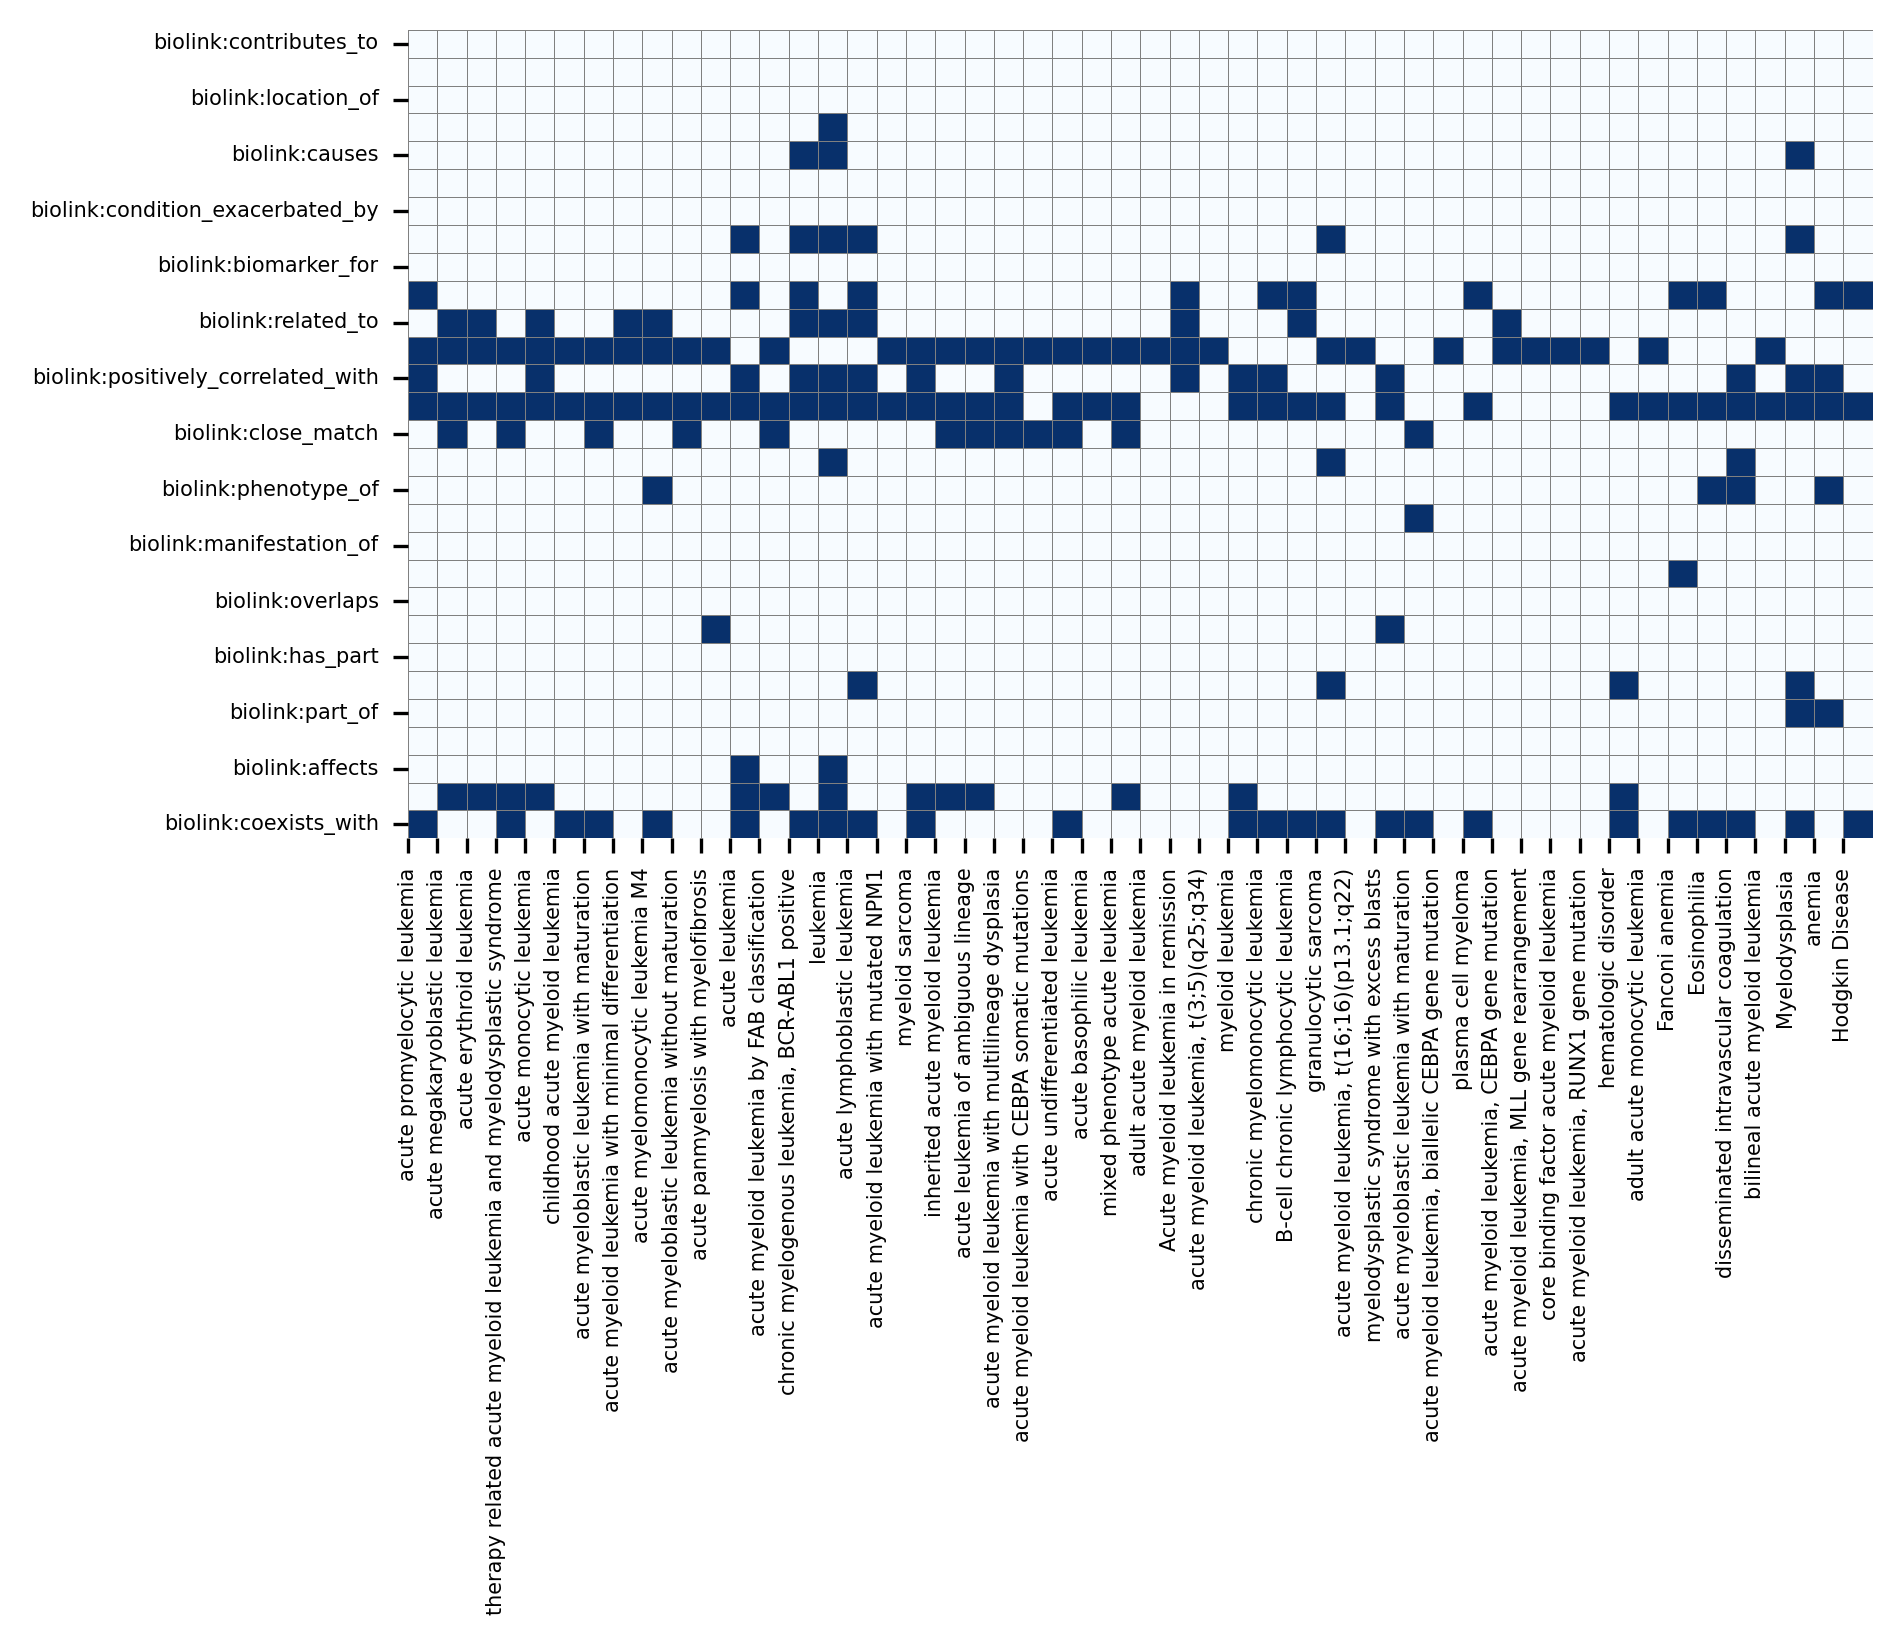

,acute promyelocytic leukemia,acute megakaryoblastic leukemia,acute erythroid leukemia,therapy related acute myeloid leukemia and myelodysplastic syndrome,acute monocytic leukemia,childhood acute myeloid leukemia,acute myeloblastic leukemia with maturation,acute myeloid leukemia with minimal differentiation,acute myelomonocytic leukemia M4,acute myeloblastic leukemia without maturation,...,autosomal recessive polycystic kidney disease,scrotal carcinoma,primary thrombocytopenia,bipolar disorder,hematologic disorder,urticaria,angiosarcoma,giant cell glioblastoma,type III hypersensitivity disease,Disorder of body system
biolink:contributes_to,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:correlated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:location_of,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:affected_by,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:causes,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:occurs_in,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:condition_exacerbated_by,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:preceded_by,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:biomarker_for,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:associated_with,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed, 
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

In [ ]:
result_ranked_by_primary_infores

In [ ]:
from TCT import TCT_Visualization

dic_graph = TCT_Visualization.visualize_neighborhood_graph(result, show_label=True, height="500", width="100%")

In [ ]:
# End of the example
